In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


c:\Users\dssua\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [4]:
#leemos el dataset de ventas finales para predecir ventas futuras
df_ventas_finales = pd.read_excel("F:\\Documentos\\PF Inventory\\Df_ventas_finales.xlsx", engine="openpyxl")

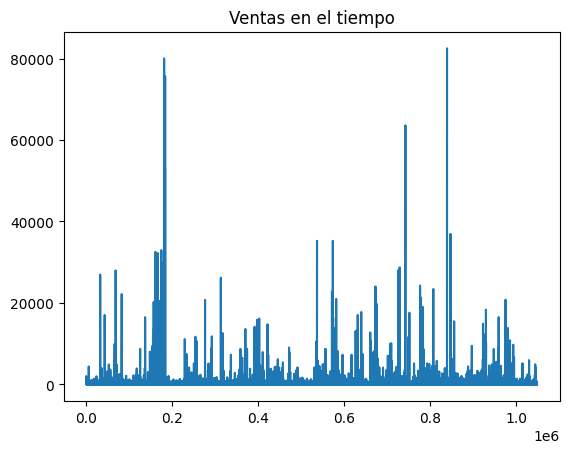

In [6]:
#generamos un grafico para ver outleers y tendencias
df_ventas_finales['Total_venta'].plot()
plt.title('Ventas en el tiempo')
plt.show()

C:\Users\dssua\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


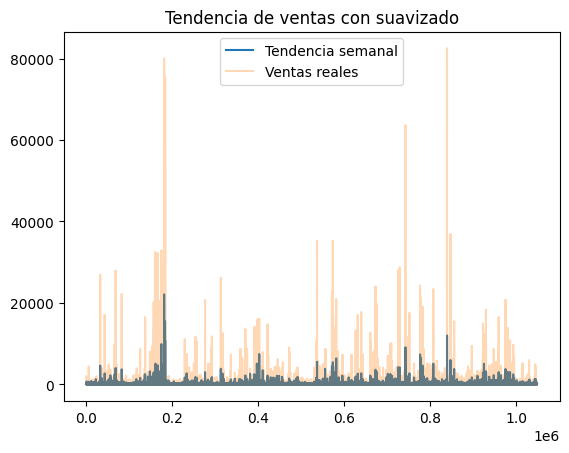

In [7]:
df_ventas_finales['Total_venta'].rolling(window=7).mean().plot(label='Tendencia semanal')
df_ventas_finales['Total_venta'].plot(alpha=0.3, label='Ventas reales')
plt.legend()
plt.title('Tendencia de ventas con suavizado')
plt.show()


In [10]:
from scipy.stats import zscore
df_ventas_finales['zscore'] = zscore(df_ventas_finales['Total_venta'])
outliers = df_ventas_finales[df_ventas_finales['zscore'].abs() > 3]
print("Outliers detectados:")
print(outliers)


Outliers detectados:
               Id_Inventario  Tienda  Marca                   Descripcion  \
95       1_hardersfield_1023       1   1023   hennessy_vsop_cognac_+_50ml   
96       1_hardersfield_1023       1   1023   hennessy_vsop_cognac_+_50ml   
149      1_hardersfield_1024       1   1024       hennessey_vs_+vsop_50ml   
530      1_hardersfield_1112       1   1112  ardbeg_exploration_pk_+50mls   
1366     1_hardersfield_1233       1   1233       jack_daniels_no_7_black   
...                      ...     ...    ...                           ...   
1043438     9_blackpool_4261       9   4261        capt_morgan_spiced_rum   
1043440     9_blackpool_4261       9   4261        capt_morgan_spiced_rum   
1044417     9_blackpool_4903       9   4903          bacardi_superior_rum   
1045125      9_blackpool_539       9    539                bowman's_vodka   
1045131      9_blackpool_539       9    539                bowman's_vodka   

         Cantidad_ventas  Subtotal  Precio_unidad Fech

## vamos a utilizar el modelo Prophet ya que nos sirve para series temporales y buscar predicciones de ventas futuras

### 🧠 Paso 1: Preparar los datos

In [14]:

#para el modelo prophet necesitamos un dataframe con dos columnas, ds (fecha) y y (valor a predecir) en este caso va hacer la cantidad de ventas
df = df_ventas_finales[['Fecha_venta', 'Cantidad_ventas']].rename(columns={'Fecha_venta': 'ds', 'Cantidad_ventas': 'y'})


### 🔮Entrenamos el modelo y realizamos la predicción

In [16]:
modelo = Prophet()
modelo.fit(df)

18:57:55 - cmdstanpy - INFO - Chain [1] start processing
19:01:44 - cmdstanpy - INFO - Chain [1] done processing


### 📅 Paso 3: Creamos la prediccion de un trismestre(90 dias) ya que las ventas son solo de dos meses

In [17]:
futuro = modelo.make_future_dataframe(periods=90)

### 📈 Paso 4: Generar predicciones

In [18]:
predicciones = modelo.predict(futuro)


### 🎯 Paso 5: Visualizar resultados

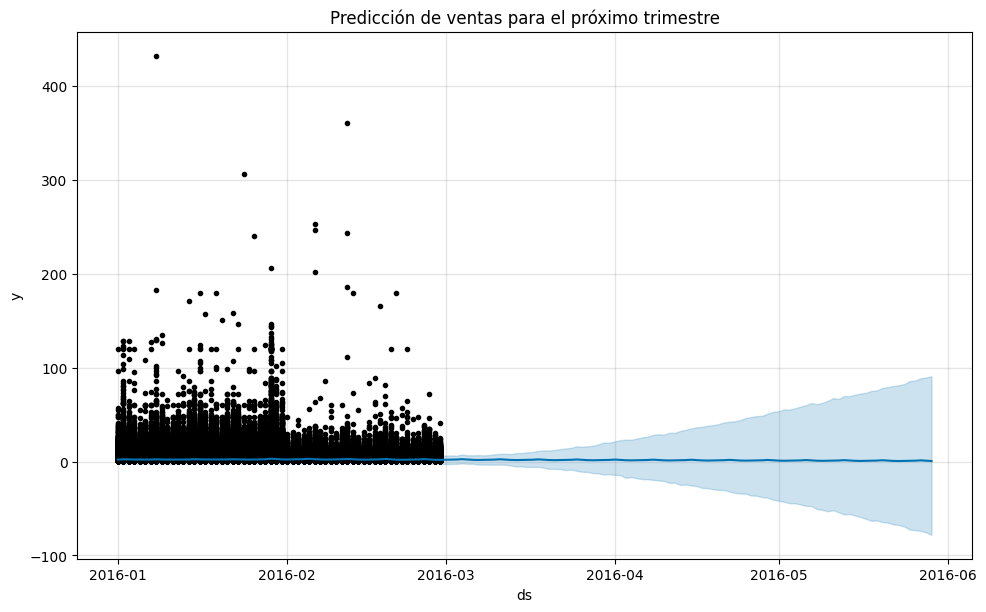

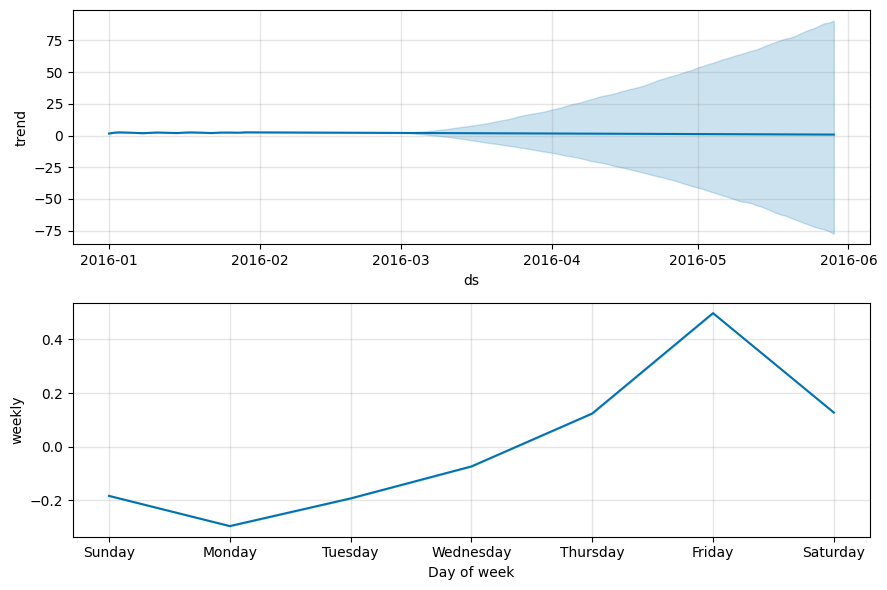

In [19]:
modelo.plot(predicciones)
plt.title('Predicción de ventas para el próximo trimestre')
plt.show()

modelo.plot_components(predicciones)
plt.show()
